In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [3]:
model = LinearRegression()

In [4]:
data = {
    "Experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Education": [12, 12, 14, 14, 16, 16, 16, 18, 18, 18],
    "Age": [21, 22, 24, 25, 27, 28, 29, 31, 33, 35],
    "Salary": [25000, 28000, 35000, 40000, 50000,
               58000, 62000, 72000, 80000, 90000]
}


In [5]:
df = pd.DataFrame(data)
print(df)
X = df[["Experience", "Education", "Age"]]
y = df["Salary"]

   Experience  Education  Age  Salary
0           1         12   21   25000
1           2         12   22   28000
2           3         14   24   35000
3           4         14   25   40000
4           5         16   27   50000
5           6         16   28   58000
6           7         16   29   62000
7           8         18   31   72000
8           9         18   33   80000
9          10         18   35   90000


In [6]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[1571.43,-428.57,4000. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Experience','Education','Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5.8e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [8]:
new_person = pd.DataFrame([[6, 16, 29]], columns=["Experience", "Education", "Age"])
predicted_salary = model.predict(new_person)
print("Predicted Salary of new person:", predicted_salary)
predicted_salary = model.predict(X_test)
print("Predicted Salary of test samples:", predicted_salary)


Predicted Salary of new person: [60571.42857143]
Predicted Salary of test samples: [80428.57142857 28000.        ]


In [9]:
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model Coefficients: [1571.42857143 -428.57142857 4000.        ]
Model Intercept: -57999.99999999991


In [10]:
errors  = abs(y_test.values - predicted_salary)
mae = errors.mean()
print("errors:", errors)
print("MAE:", mae)

errors: [428.57142857   0.        ]
MAE: 214.28571428571013


In [11]:
#Using scikit-learn's mean_absolute_error function
mae_sklearn = mean_absolute_error(y_test, predicted_salary)
print("MAE (scikit-learn):", mae_sklearn)

MAE (scikit-learn): 214.28571428571013


In [12]:
errors = y_test.values - predicted_salary
squared_errors = errors ** 2
mse = squared_errors.mean()
print("errors:", errors)
print("MSE:", mse)

errors: [-428.57142857    0.        ]
MSE: 91836.734693874


In [13]:
#Using scikit-learn's mean_squared_error function
mse_sklearn = mean_squared_error(y_test, predicted_salary)
print("MSE (scikit-learn):", mse_sklearn)

MSE (scikit-learn): 91836.734693874


In [14]:
df = pd.read_csv(r"C:\Users\Noir\Downloads\BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [15]:
X =(df[["crim", "zn", "indus", "chas", "nox", "rm", "age", "dis", "rad", "tax", "ptratio", "b", "lstat"]])
y = df["medv"]


In [16]:
print(X.isna().sum())
print(y.isna().sum())

X = X.copy()
X["rm"] = X["rm"].fillna(X["rm"].mean())
print(X.isna().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
dtype: int64
0
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
dtype: int64


In [17]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.11, 0.03, 0.04,...,-0.92, 0.01,-0.51]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['crim','zn','indus',...,'ptratio','b','lstat']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,30.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [18]:
predicted_price = model.predict(X_test)
price_table = pd.DataFrame({"Actual Price": y_test, "Predicted Price": predicted_price})
print(price_table)

     Actual Price  Predicted Price
173          23.6        28.981419
274          32.4        36.014232
491          13.6        14.824309
72           22.8        25.022936
452          16.1        18.770774
..            ...              ...
412          17.9        -0.157994
436           9.6        13.683250
411          17.2        16.175373
86           22.5        22.260247
75           21.4        24.473668

[102 rows x 2 columns]


In [19]:
from sklearn.metrics import mean_squared_error
MSE = mean_squared_error(y_test, predicted_price)
print("Mean Squared Error:", MSE)

Mean Squared Error: 24.404825188146408


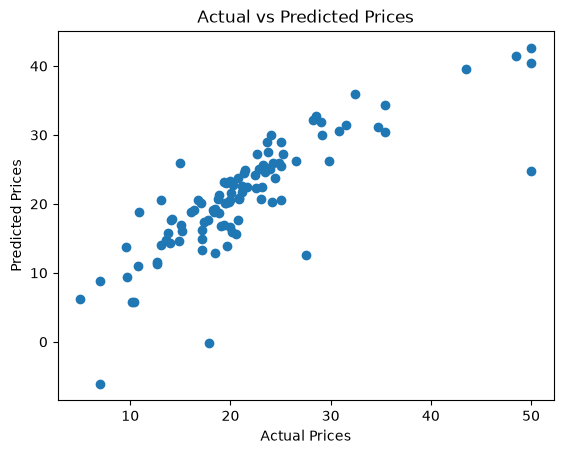

In [20]:
plt.scatter(y_test, predicted_price)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [21]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, predicted_price)
print("R-squared:", r2)

R-squared: 0.6672089705941889
